In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 4
N_TICKS = 1000
CASH = 10 ** 3
EXCHANGE_VOLUME = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [5]:
# метрика лосса: mse где нормировка по корню дисперсии: самое научное, что я придумал/нашел
# + байесовское обучение оптуной, все диапазоны я выбрал интуитивно руководствуясь логикой/статьями
def loss_mse(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += ((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0]) ** 2
    return error / len(num + arrs)

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 5, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 5, 100),
        'Chartist': trial.suggest_int('Chartist', 5, 100),
        'Universalist': trial.suggest_int('Universalist', 5, 100),
        'MarketMaker': trial.suggest_int('MarketMaker', 0, 1),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 1e-1, 1e2, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 1e-2, 1e1, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 50, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 5, log=True)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, CASH) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, CASH) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, CASH) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, CASH) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, CASH) for _ in range(params['MarketMaker'])],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_mse(target_params, model_params))
        except Exception:
            continue

    if len(errors) != N_RUNS:
        return 100000
    return float(np.mean(errors))

In [6]:
# само обучение
study_mse = optuna.create_study(study_name="calibration_mse_v2 (Exceptions fixed)", direction="minimize", storage="sqlite:///calibration_mse_2.db",  load_if_exists=True)
study_mse.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study_mse.best_params
best_score = study_mse.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-03-30 00:16:18,156] Using an existing study with name 'calibration_mse_v2 (Exceptions fixed)' instead of creating a new one.
Best trial: 480. Best value: 0.158861:   0%|          | 1/500 [00:02<18:59,  2.28s/it]

[I 2026-03-30 00:16:20,462] Trial 500 finished with value: 0.5070529772711688 and parameters: {'Random': 83, 'Fundamentalist': 5, 'Chartist': 10, 'Universalist': 6, 'MarketMaker': 1, 'Transaction_cost': 0.0010484761699498357, 'Std': 1.5928294111973218, 'Std_Random': 0.5819951058153264, 'Avg_Traders': -2.2397864654669015, 'Last_Step': 0.4669957774390394, 'Last_Ret': 0.046935131508754765, 'Noisy_Level': 1.4637264911716013}. Best is trial 480 with value: 0.1588606807117378.


Best trial: 480. Best value: 0.158861:   0%|          | 2/500 [00:07<31:04,  3.74s/it]

[I 2026-03-30 00:16:25,228] Trial 501 finished with value: 110.17775096778806 and parameters: {'Random': 85, 'Fundamentalist': 7, 'Chartist': 60, 'Universalist': 9, 'MarketMaker': 1, 'Transaction_cost': 0.0012463762042729972, 'Std': 1.4313346454395313, 'Std_Random': 0.39972981165386945, 'Avg_Traders': -1.9219253594102252, 'Last_Step': 0.42570669090836644, 'Last_Ret': 0.027381979160224022, 'Noisy_Level': 1.137939722242691}. Best is trial 480 with value: 0.1588606807117378.


Best trial: 480. Best value: 0.158861:   1%|          | 3/500 [00:11<32:35,  3.93s/it]

...

Best trial: 480. Best value: 0.158861:   5%|▍         | 23/500 [01:52<40:52,  5.14s/it]

[I 2026-03-30 00:18:10,373] Trial 522 finished with value: 0.6302506907869074 and parameters: {'Random': 86, 'Fundamentalist': 7, 'Chartist': 60, 'Universalist': 8, 'MarketMaker': 1, 'Transaction_cost': 0.0007068544974072977, 'Std': 1.9384702709781798, 'Std_Random': 0.3336886203363069, 'Avg_Traders': -2.372002387723071, 'Last_Step': 0.5136695736119279, 'Last_Ret': 0.04357286976521319, 'Noisy_Level': 0.8979754876097327}. Best is trial 480 with value: 0.1588606807117378.


Best trial: 480. Best value: 0.158861:   5%|▍         | 23/500 [01:56<40:09,  5.05s/it]

[W 2026-03-30 00:18:14,346] Trial 523 failed with parameters: {'Random': 82, 'Fundamentalist': 9, 'Chartist': 56, 'Universalist': 7, 'MarketMaker': 1, 'Transaction_cost': 0.0009439682407684733, 'Std': 54.28207811461516, 'Std_Random': 0.45246841632024964, 'Avg_Traders': -1.9717898924172823, 'Last_Step': 0.4906654604825893, 'Last_Ret': 0.05487047006589943, 'Noisy_Level': 1.2208151819837914} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\rodion\files\ABM system\1D-ABM\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\rodion\AppData\Local\Temp\ipykernel_9680\3546485600.py", line 47, in objective
    simulator2.simulate(N_TICKS, silent=True)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rodion\files\ABM system\1D-ABM\AgentBasedModel\simulator\simulator.py", line 90, in simulate
    trader.call()
    ~~~~~~~~~~~^^
  File "C:\Users\rodion\file

KeyboardInterrupt: 

[I 2026-03-30 11:23:26,246] Using an existing study with name 'calibration_mse_v2 (Exceptions fixed)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_20856\3866188282.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_mse)


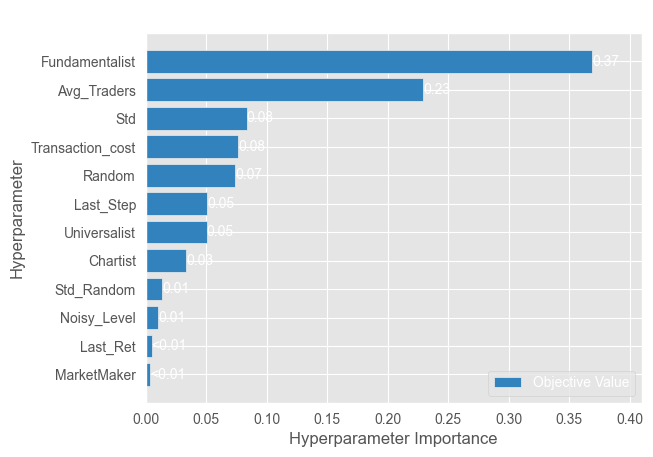

In [3]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study_mse = optuna.create_study(study_name="calibration_mse_v2 (Exceptions fixed)", direction="minimize", storage="sqlite:///calibration_mse_2.db",  load_if_exists=True)
plot_param_importances(study_mse)
plt.show()

In [4]:
best_params = study_mse.best_params
best_score = study_mse.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

Best params: {'Random': 87, 'Fundamentalist': 7, 'Chartist': 57, 'Universalist': 5, 'MarketMaker': 1, 'Transaction_cost': 0.000961517396642084, 'Std': 1.493468735287384, 'Std_Random': 0.30913258096029245, 'Avg_Traders': -2.0078876314314047, 'Last_Step': 0.5046456825414161, 'Last_Ret': 0.026453029682668366, 'Noisy_Level': 0.8738803560680672}
Best Score: 0.1588606807117378
